### To make a complete system, first we make them in ipynb and later make corresponding python .py files for each

#### AI Tutor is a multi-agent agentic system that follows multi-agent architecture.

##### We add multiple specialized agents to the AI Tutor that works autonomouly parallely or sequentially based upon the requirements to reach/achieve the goal. Supervisor being at the top makes the goal into sub-goals and provide the sub-goal to corresponding agents based upon the specialization

##### All the necessary imports are:

In [1]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Optional, List, Annotated
from langchain_ollama import OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.graph.message import add_messages
from langgraph.types import Command, Interrupt
from dotenv import load_dotenv
import os
import operator

c:\Users\Nitro\Desktop\Desk\AITutor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

### Supervisor and Workers:- 

##### We need to make a supervisor agent where all the workers agent that are going to work and their use are given to the supervisor using prompt so that it can make reasoning and then handsoff the corresponding agent.

##### The supervisor should route the task to the corresponding agent in such a way that the whole task could be done by the agent in and no other agent's capable work should be given to the agent. Such prompt should be given to the supervisor agent.

##### Each agent will get the task that only belongs to it and then when the agent does its work then the agent will change the state due to which the supervisor can get all the changes done by the agent and go for the next job to delegate.

##### It's just like the Orchestrator.

### tools

In [3]:
llm = ChatGroq(
    api_key=os.getenv("api_key"),
        model="llama-3.3-70b-versatile"
)

# llm = ChatNVIDIA(
#   model="openai/gpt-oss-20b",
#   api_key="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", 
#   temperature=1,
#   top_p=1,
#   max_tokens=4096,
# )


# llm = ChatOllama(model = "llama3.2")

tavily_research_tool = TavilySearch(max_results=3, include_answer= True, search_depth= "advanced", auto_parameters=True)
tavily_research_tool.invoke({"query" : "What is llm?"})

{'query': 'What is llm?',
 'response_time': 2.24,
 'follow_up_questions': None,
 'answer': 'A large language model (LLM) is an advanced AI system trained on vast datasets to generate and understand human language. LLMs can perform tasks like answering questions and writing content. They use deep learning and neural networks to analyze text.',
 'images': [],
 'results': [{'url': 'https://ask.library.arizona.edu/faq/407985',
   'title': 'What is a large language model (LLM)?',
   'content': '## What is a large language model (LLM)?\n\nA large language model (LLM) is a type of artificial intelligence that can generate human language and perform related tasks. These models are trained on huge datasets, often containing billions of words. By analyzing all this data, the LLM learns patterns and rules of language, similar to the way a human learns to communicate through exposure to language. LLMs can perform various language tasks, such as answering questions, summarizing text, translating be

In [4]:
# making dictionary for each of the agents tool

# research agent
research_tools = [tavily_research_tool]
research_tools_by_name = {tool.name : tool for tool in research_tools}

# task_specific_agent
materials_tools = []
materials_tools_by_name = {tool.name : tool for tool in materials_tools}

#rag_agent
rag_tools = []
rag_tools_by_name = {tool.name : tool for tool in rag_tools}

# youtube_agent
youtube_tools = []
youtube_tools_by_name = {tool.name : tool for tool in youtube_tools}

### LLM for each agents with tools binded to it

In [5]:
llm = ChatGroq(model= os.getenv("model"), api_key=os.getenv("api_key"))
research_agent_with_tool =  llm.bind_tools([tavily_research_tool])
rag_agent_with_tool = llm.bind_tools(rag_tools)
youtube_agent_with_tool = llm.bind_tools(youtube_tools)
task_agent_with_tool = llm.bind_tools(materials_tools)


In [6]:
# BaseModels

class Task(BaseModel):
    '''contains information of each step of the plan'''
    id : int = Field(description="id of the step")
    goal : str = Field(description="goal that the user needs to reach after reding the task's answer")
    tool_required : bool = Field("True if research tool is required and False if not")

task_schema = PydanticOutputParser(pydantic_object=Task)

class Plan(BaseModel):
    '''list of plan'''
    plan : list[Task]

plan_schema = PydanticOutputParser(pydantic_object=Plan)

class Goal(BaseModel):
    '''contains the goal for the particualr agent with name of the agent'''
    # title : str = Field(description = "name or title based upon the user query")
    id : int = Field(description = "id of the agent in integer")
    agent : Literal['Researcher', 'RAG', 'TaskSpecific', 'YoutubeAgent', 'END'] = Field(description="one specific agent that is to be choosen for the work")
    sub_goal : str = Field(description = "goal that is provided the to the specific one agent")

sub_goal_schema = PydanticOutputParser(pydantic_object=Goal)

class RAG_agent_type(BaseModel):
    pass


class Youtube_agent_type(BaseModel):
    pass


class Task_specific_type(BaseModel):
    pass


In [35]:
# id and agent_name
mapper = {
    1 : 'Researcher',
    5 : 'END'
}
# Research Graph
class ResearchState(TypedDict):
    # Sub-goal given by the supervisor
    sub_goal : str
    
    # plan made by the researcher agent
    agent_plan : Annotated[list[Task], operator.add]

    # explaination done by agent (either toolMessage or the AiMessage)
    agent_explain : Annotated[list[str], operator.add]

    # key points covered by this agent
    key_points : Annotated[list[str], operator.add]


# MaterialGraph (Q/A_and_flashcards and study planner))
class MaterialsState(TypedDict):
    # sub-goal given by the supervisor(Helper Supervisor)
    sub_goal : str


class RAGState(TypedDict):
    pass

class YoutubeState(TypedDict):
    pass

# Main State
class State(TypedDict):
    goal : str
    title : str
    need_RAG : bool
    agent_id : Annotated[list[int], operator.add]
    Researcher : ResearchState
    YoutubeAgent : Youtube_agent_type
    TaskSpecific : Task_specific_type


In [8]:
def Planner(state : ResearchState):
    goal = state['sub_goal']
    # prompt = PromptTemplate(template="goal : {sub_goal} \n\n{format}", input_variables=['sub_goal'], partial_variables={"format" : task_schema.get_format_instructions()})
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You as an excellent planner agent that can generate a beautiful productive plan to give to the worker agents to execute on the basis of your plan. Workers agents will explain based on you plan so make the plan good. 
         Total number of steps must be less than 7. \n
         
         ****TOOL USAGE RULE****
            Set "tool_required" = true ONLY if the goal includes ANY time-dependent intent.

            Time-dependent means:
            - current
            - latest
            - recent
            - today
            - now
            - trending
            - live
            - real-time
            - updated information

            If ANY of these appear or are implied → tool_required = true

            Otherwise (theoretical, general, timeless knowledge) → tool_required = false

            You MUST strictly follow this mapping.\n
                    
         ***Structure***
         Just give me list of steps in the following JSON format:\n
        {plan}\n\n
         where each task is in the form of:\n
         {task}"""),
        ("human", "Goal : {goal}")]).partial(plan = plan_schema.get_format_instructions(), task = task_schema.get_format_instructions())
    chain = prompt | llm | plan_schema
    plan = chain.invoke({'goal' : goal}).plan
    print(plan)
    key_points = []
    agent_plan = []
    for step in plan:
        agent_plan.append({
            'id' : step.id,
            'goal' : step.goal,
            'tool_required' : step.tool_required
        })
        key_points.append(step.goal)
    print(agent_plan)
    return {'agent_plan' : agent_plan, 'key_points' : key_points}

In [9]:
Planner(ResearchState(sub_goal="RNN"))

[Task(id=1, goal='Understand the basics of Recurrent Neural Networks (RNNs), including their structure and types.', tool_required=False), Task(id=2, goal='Learn about the applications of RNNs, such as natural language processing, speech recognition, and time series prediction.', tool_required=False), Task(id=3, goal='Familiarize yourself with popular RNN architectures like LSTM (Long Short-Term Memory) and GRU (Gated Recurrent Unit).', tool_required=False), Task(id=4, goal='Practice implementing a simple RNN or LSTM model using a deep learning framework like TensorFlow or PyTorch.', tool_required=True), Task(id=5, goal='Experiment with a real-world dataset to train and evaluate the performance of your RNN model.', tool_required=True), Task(id=6, goal="Analyze the results, understand the challenges faced, and explore ways to improve the model's performance.", tool_required=False)]
[{'id': 1, 'goal': 'Understand the basics of Recurrent Neural Networks (RNNs), including their structure an

{'agent_plan': [{'id': 1,
   'goal': 'Understand the basics of Recurrent Neural Networks (RNNs), including their structure and types.',
   'tool_required': False},
  {'id': 2,
   'goal': 'Learn about the applications of RNNs, such as natural language processing, speech recognition, and time series prediction.',
   'tool_required': False},
  {'id': 3,
   'goal': 'Familiarize yourself with popular RNN architectures like LSTM (Long Short-Term Memory) and GRU (Gated Recurrent Unit).',
   'tool_required': False},
  {'id': 4,
   'goal': 'Practice implementing a simple RNN or LSTM model using a deep learning framework like TensorFlow or PyTorch.',
   'tool_required': True},
  {'id': 5,
   'goal': 'Experiment with a real-world dataset to train and evaluate the performance of your RNN model.',
   'tool_required': True},
  {'id': 6,
   'goal': "Analyze the results, understand the challenges faced, and explore ways to improve the model's performance.",
   'tool_required': False}],
 'key_points': 

In [14]:
def Researcher(state : ResearchState):
    plan = state['agent_plan']
    explaination = []
    prompt = ChatPromptTemplate.from_messages([
        ('system', """
    You are a **Research & Explanation Agent**.

    You will receive **one task at a time**. Your job is to produce content that directly satisfies the goal.
    Rules:
    - Focus only on the current task. Do not explain unrelated concepts.
    - Adapt explanation to goal type: definition, math, numeric example, summary, etc.
    - Output concise, relevant explanation. No forced headings, templates, or extra text.
    """),
        ('human', "task : {task}")
    ])
    for step in plan:
        print(step)
        if step['tool_required'] == True:
            # do the llm call with the tool_required
            output = research_agent_with_tool.invoke(step['goal'])
            if not output.tool_calls :
                print("⚠️No tools called despite of the tool_required : TRUE")
                print(output.content)
            else:
                tool_recommended = output.tool_calls[0]
                tool_name = research_tools_by_name[tool_recommended['name']]
                tool_output = tool_name.invoke(tool_recommended['args'])['answer']
                print(tool_output)
                explaination.append(tool_output)
        else:
            chain = prompt | llm | StrOutputParser()
            # result = chain.invoke(step['goal'])
            message = HumanMessage(content=step['goal'])  # wrap goal
            result = chain.invoke([message])              
            print(result)
            explaination.append(result)

    return {'agent_explain' : explaination}

In [19]:
Researcher({'agent_plan': [{'id': 1,
   'goal': 'Identify current trends in AI',
   'tool_required': True},
  {'id': 2,
   'goal': 'Analyze recent developments in AI research',
   'tool_required': True},
  {'id': 3,
   'goal': 'Explore applications of AI in various industries',
   'tool_required': False},
  {'id': 4,
   'goal': 'Summarize key findings and insights on AI trends',
   'tool_required': False},
  {'id': 5,
   'goal': 'Provide recommendations for future AI research and development',
   'tool_required': False},
  {'id': 6,
   'goal': 'Present the final report on AI trends',
   'tool_required': False}]})

{'id': 1, 'goal': 'Identify current trends in AI', 'tool_required': True}
Current AI trends include increased GenAI integration and adoption in workplaces, along with advancements in multimodal AI and coding agents. AI is becoming more accessible and strategic, transforming business operations.
{'id': 2, 'goal': 'Analyze recent developments in AI research', 'tool_required': True}
Recent developments in AI research include significant advancements in materials discovery and advanced manufacturing. A new AI-driven framework extracted over one million polymer-property records from 681,000 full-text journal articles, showcasing the computational efficiency and accuracy of different AI models. Generative AI has also made breakthroughs by using GANs and VAEs to design new materials, marking a shift in materials discovery. In the realm of coding and task completion, Chinese AI models like MiniMax M2.5 have gained traction due to their performance and lower cost compared to competitors. Additi

{'agent_explain': ['Current AI trends include increased GenAI integration and adoption in workplaces, along with advancements in multimodal AI and coding agents. AI is becoming more accessible and strategic, transforming business operations.',
  'Recent developments in AI research include significant advancements in materials discovery and advanced manufacturing. A new AI-driven framework extracted over one million polymer-property records from 681,000 full-text journal articles, showcasing the computational efficiency and accuracy of different AI models. Generative AI has also made breakthroughs by using GANs and VAEs to design new materials, marking a shift in materials discovery. In the realm of coding and task completion, Chinese AI models like MiniMax M2.5 have gained traction due to their performance and lower cost compared to competitors. Additionally, AI scientists are becoming essential collaborators in life sciences research, working alongside human scientists to propose nove

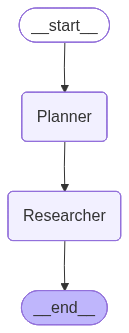

In [16]:
researchGraph = StateGraph(ResearchState)

researchGraph.add_node("Planner", Planner)
researchGraph.add_node("Researcher", Researcher)

researchGraph.add_edge(START, "Planner")
researchGraph.add_edge("Planner", "Researcher")
researchGraph.add_edge("Researcher", END)

ResearcherSubGraph = researchGraph.compile()
ResearcherSubGraph

In [17]:
ResearcherSubGraph.invoke({'sub_goal' : "explain self sttention clearly"})

[Task(id=1, goal='Introduce the concept of self-attention', tool_required=False), Task(id=2, goal='Explain the problem that self-attention solves, specifically the limitation of traditional recurrent neural networks (RNNs) in handling long-range dependencies', tool_required=False), Task(id=3, goal='Describe the self-attention mechanism, including the query, key, and value vectors, and how they are used to compute attention weights', tool_required=False), Task(id=4, goal='Provide a step-by-step example of how self-attention works, including the calculation of attention weights and the weighted sum of value vectors', tool_required=False), Task(id=5, goal='Highlight the benefits of self-attention, including its ability to handle long-range dependencies and its parallelization capabilities', tool_required=False), Task(id=6, goal='Summarize the key points of self-attention and provide examples of its applications in natural language processing and computer vision', tool_required=False)]
[{'

{'sub_goal': 'explain self sttention clearly',
 'agent_plan': [{'id': 1,
   'goal': 'Introduce the concept of self-attention',
   'tool_required': False},
  {'id': 2,
   'goal': 'Explain the problem that self-attention solves, specifically the limitation of traditional recurrent neural networks (RNNs) in handling long-range dependencies',
   'tool_required': False},
  {'id': 3,
   'goal': 'Describe the self-attention mechanism, including the query, key, and value vectors, and how they are used to compute attention weights',
   'tool_required': False},
  {'id': 4,
   'goal': 'Provide a step-by-step example of how self-attention works, including the calculation of attention weights and the weighted sum of value vectors',
   'tool_required': False},
  {'id': 5,
   'goal': 'Highlight the benefits of self-attention, including its ability to handle long-range dependencies and its parallelization capabilities',
   'tool_required': False},
  {'id': 6,
   'goal': 'Summarize the key points of se

In [20]:
def MiniSuervisor(state : MaterialsState):
    # get the sub-goal from the user and this will chose which agent to route the goal to with what goal.
    pass

def StudyPlanner(state : MaterialsState):
    # gets the goal to make a study plan effectively
    pass

def QAandFlashCards(state : MaterialsState):
    pass

def SubAgentSelection(state : MaterialsState):
    if 1:
        return "QAandFlashCards"
    
    elif 2:
        return "StudyPlanner"
    
    elif 3:
        return "END"

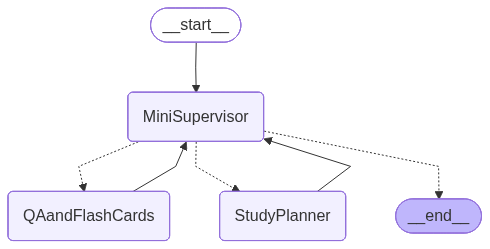

In [21]:
subGraph = StateGraph(State)
subGraph.add_node("MiniSupervisor", MiniSuervisor)
subGraph.add_node("StudyPlanner", StudyPlanner)
subGraph.add_node("QAandFlashCards", QAandFlashCards)

subGraph.add_edge(START, "MiniSupervisor")
subGraph.add_conditional_edges("MiniSupervisor", SubAgentSelection,{"QAandFlashCards" : "QAandFlashCards", "StudyPlanner" : "StudyPlanner"})
subGraph.add_edge("QAandFlashCards", "MiniSupervisor")
subGraph.add_edge("StudyPlanner", "MiniSupervisor")
subGraph.add_edge("MiniSupervisor", END)

subSystem = subGraph.compile()

subSystem

In [42]:
# FOR THE SUPERVISOR NODE
def Supervisor(state : State):
    goal = state['goal']
    researcher = state.get('Researcher', {}).get("key_points", [])
    agent_ids = state.get('agent_id', [])
    record = {}
    for agent_id in mapper:
        if agent_id in agent_ids:
            record[agent_id] = "used"

    print("Already used agents :", agent_ids)
    print(goal)
    print(researcher)
    prompt = ChatPromptTemplate([
        ('system', """You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n
         ****Specialized agents(worker agents) id and their speciality****
         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)
         5 --> END : If no any agents is required now.\n\n
        
         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n

         ****Specialized agents(worker agents) name and their work till now*****
         Researcher : {researcher_work}
         
         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn't been used yet. \n\n
         
         ****Agents state****
         {record}

         "used" cannot be used again
         ****Structure****
    
         To provide the specific agent you have to return the goal in the following structure\n

         {format}\n\n

        ****Rules****
         
         - Don't use already used agents
         - Only provide goal to the specialized agent goal when the query seems to demand.
         - Depending upon the user query, its meaning(as you are Tutor) and work done by workers till now, you must call only the required agent at a time,
         - Dont use the used agent twice.

         """),
        ('human', "Goal/Query from user : {goal}")
    ]).partial(format = sub_goal_schema.get_format_instructions(), researcher_work  = researcher, record = record)
    print("⚠️"*50)
    print(prompt.invoke({'goal' : goal}))
    print("⚠️"*50)
    # Generate the title for it
    chain = prompt | llm | sub_goal_schema
    response = chain.invoke({'goal' : goal})
    print('Supervisor Completed ✅')
    print(type(response.id))
    return {'agent_ids' : [response.id], response.agent : {'sub_goal' : response.sub_goal}}

In [43]:
Supervisor(State(goal="Self-Attention"))

Already used agents : []
Self-Attention
[]
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
messages=[SystemMessage(content='You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n\n         ****Specialized agents(worker agents) id and their speciality****\n         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)\n         5 --> END : If no any agents is required now.\n\n\n\n         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n\n\n         ****Specialized agents(worker agents) name and their work till now*****\n         Researcher : []\n\n         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn\'t been used yet. \n\n\n\n         ****Agents state****\n         {}\n\n         "used" cannot be used again\n         ****Structure****\n\n   

{'agent_ids': [1],
 'Researcher': {'sub_goal': 'Explain the concept of Self-Attention in deep learning and its applications.'}}

In [24]:
# FOR THE RESEARCH NODE
# it should be complex as its job is not only to extract one knowledge but many aspects like what, how, why, when, exmaples, mechanism etc.
def Researcher(state : State):
    sub_goal = state['Researcher']['sub_goal']
    print("Researcher agent's Goal: ",sub_goal)
    response = ResearcherSubGraph.invoke({'sub_goal' : sub_goal})
    print(response)
    print('Research Completed ✅')
    return {'Researcher' : {
        'sub_goal' : response['sub_goal'],
        'agent_plan' : response['agent_plan'],
        'agent_explain' : response['agent_explain'],
        'key_points' : response['key_points']
    }}

In [25]:
Researcher(State(Researcher= {
    'sub_goal' : "Self Attention",
}))

Researcher agent's Goal:  Self Attention
[Task(id=1, goal='Understand the concept of Self Attention', tool_required=False), Task(id=2, goal='Explain the mechanism of Self Attention in Transformer models', tool_required=False), Task(id=3, goal='Describe the importance of Self Attention in natural language processing tasks', tool_required=False), Task(id=4, goal='Provide examples of how Self Attention is used in real-world applications', tool_required=False), Task(id=5, goal='Discuss the advantages and limitations of using Self Attention', tool_required=False), Task(id=6, goal='Summarize key points about Self Attention for future reference', tool_required=False)]
[{'id': 1, 'goal': 'Understand the concept of Self Attention', 'tool_required': False}, {'id': 2, 'goal': 'Explain the mechanism of Self Attention in Transformer models', 'tool_required': False}, {'id': 3, 'goal': 'Describe the importance of Self Attention in natural language processing tasks', 'tool_required': False}, {'id': 4,

{'Researcher': {'sub_goal': 'Self Attention',
  'agent_plan': [{'id': 1,
    'goal': 'Understand the concept of Self Attention',
    'tool_required': False},
   {'id': 2,
    'goal': 'Explain the mechanism of Self Attention in Transformer models',
    'tool_required': False},
   {'id': 3,
    'goal': 'Describe the importance of Self Attention in natural language processing tasks',
    'tool_required': False},
   {'id': 4,
    'goal': 'Provide examples of how Self Attention is used in real-world applications',
    'tool_required': False},
   {'id': 5,
    'goal': 'Discuss the advantages and limitations of using Self Attention',
    'tool_required': False},
   {'id': 6,
    'goal': 'Summarize key points about Self Attention for future reference',
    'tool_required': False}],
  'agent_explain': ["Self-attention is a mechanism used in deep learning models, particularly in transformer architectures. It allows a model to attend to different parts of its input sequence simultaneously and wei

In [26]:
def YoutubeVideos(state : State):
    pass

In [27]:
# FOR THE YOUTUBEVIDEOS NODE
def Materials(state : State):
    # We make subgraph as it will contain multiple agents in side the TaskSpecific agent:
    # Sub-Supervisor
    # Worker Agents:
        # Q/A and FlashCards
        # StudyPlanner
    # All agents will have same tool as not needed much
    pass

In [28]:
# FOR THE RAG AGENT
def RAG(state : State):
    # we have retriever that is used to retrieve the corresponding queries asnwer from the document
    pass

In [29]:
# at the end when all the task are completed then all the results from each agent are synthesized into proper format
def Synthesizer(state : State):
    print("Synthesizer ✅")

    return {}
    # At last synthesize the whole blog/goal that are broken down and submitted to all the agents into one single organized form

In [30]:
def AgentSelection(state : State):
    agent_id = state['agent_id'][-1]
    print("agent id",type(agent_id))
    print("next ---->", agent_id)
    if agent_id == 1:
        return "Researcher"
    elif agent_id == 2: 
        return "RAG"
    elif agent_id == 3:
        return "TaskSpecific"
    elif agent_id == 4:
        return "YoutubeAgent"
    else:
        return "Synthesizer"

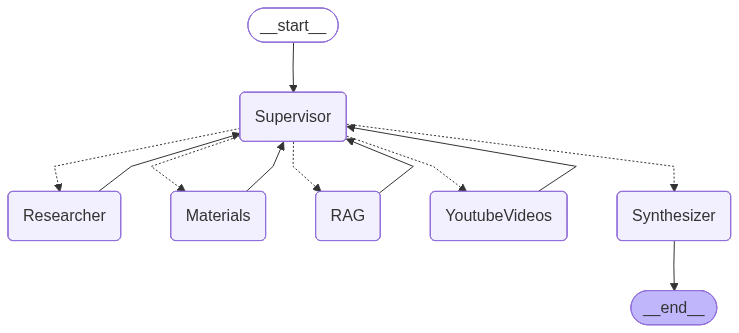

In [31]:
graph = StateGraph(State)
graph.add_node("Supervisor", Supervisor)
graph.add_node("Researcher", Researcher)
graph.add_node("Materials", Materials)    
graph.add_node("RAG", RAG)
graph.add_node("YoutubeVideos", YoutubeVideos)
graph.add_node("Synthesizer", Synthesizer)

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", AgentSelection, {"Researcher" : "Researcher", "RAG" : "RAG", "YoutubeVideos" : "YoutubeVideos", "Materials" : "Materials", "Synthesizer" : "Synthesizer"})
graph.add_edge("Researcher", "Supervisor")
graph.add_edge("RAG", "Supervisor")
graph.add_edge("Materials", "Supervisor")
graph.add_edge("YoutubeVideos", "Supervisor")
graph.add_edge("Synthesizer", END)

MainGraph = graph.compile()

MainGraph



In [44]:
MainGraph.invoke({'goal' : "Self-attention"})

Already used agents : []
Self-attention
[]
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
messages=[SystemMessage(content='You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n\n         ****Specialized agents(worker agents) id and their speciality****\n         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)\n         5 --> END : If no any agents is required now.\n\n\n\n         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n\n\n         ****Specialized agents(worker agents) name and their work till now*****\n         Researcher : []\n\n         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn\'t been used yet. \n\n\n\n         ****ALready Used Agents****\n         Dont use the agents with the following id:\n         []\n\n         **

{'goal': 'Self-attention',
 'agent_id': [1, 5],
 'Researcher': {'sub_goal': 'Research on Self-attention, its applications, and implications in deep learning models.',
  'agent_plan': [{'id': 1,
    'goal': 'Understand the concept of self-attention in deep learning',
    'tool_required': False},
   {'id': 2,
    'goal': 'Research on applications of self-attention in various deep learning models',
    'tool_required': True},
   {'id': 3,
    'goal': 'Investigate the implications of self-attention on model performance and interpretability',
    'tool_required': True},
   {'id': 4,
    'goal': 'Analyze the role of self-attention in transformer-based architectures',
    'tool_required': True},
   {'id': 5,
    'goal': 'Explore the potential limitations and challenges of using self-attention in deep learning models',
    'tool_required': True},
   {'id': 6,
    'goal': 'Summarize the key findings and takeaways from the research on self-attention',
    'tool_required': False}],
  'agent_expla

In [ ]:
output = research_agent_with_tool.invoke("What is the top 10 news on Nepal right now!")
output.tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'Nepal top 10 news now',
   'search_depth': 'advanced',
   'topic': 'news'},
  'id': 'aemcy1nq2',
  'type': 'tool_call'}]

In [ ]:
output

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'aemcy1nq2', 'function': {'arguments': '{"query":"Nepal top 10 news now","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 2113, 'total_tokens': 2165, 'completion_time': 0.127276543, 'completion_tokens_details': None, 'prompt_time': 0.061550929, 'prompt_tokens_details': None, 'queue_time': 0.044388571, 'total_time': 0.188827472}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d01a2-bab4-7722-841a-42dc6c40a630-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Nepal top 10 news now', 'search_depth': 'advanced', 'topic': 'news'}, 'id': 'aemcy1nq2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2113,